<a href="https://colab.research.google.com/github/jdtoscano94/Learning-PINNs-in-Pytorch-Physics-Informed-Machine-Learning/blob/main/2_SimpleODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [ ]:
!pip install pyDOE2

  Preparing metadata (setup.py) ... done
  Created wheel for pyDOE2: filename=pydoe2-1.3.0-py3-none-any.whl size=25613 sha256=7f4d5a8af61eb68ed873bed217db515376127b4679169bb9be4711db461e093d
  Stored in directory: /root/.cache/pip/wheels/1e/3f/af/a5227d3363bbf605ab571e9c7e35a579d36c3bb57426efee77
Successfully built pyDOE2


In [ ]:
import torch
import torch.autograd as autograd         # computation graph
from torch import Tensor                  # tensor node in the computation graph
import torch.nn as nn                     # neural networks
import torch.optim as optim               # optimizers e.g. gradient descent, ADAM, etc.

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker
from sklearn.model_selection import train_test_split

import numpy as np
import time
from scipy.stats import qmc

def lhs(n, samples):
    sampler = qmc.LatinHypercube(d=n)
    return sampler.random(n=samples)
import scipy.io


#Set default dtype to float32
torch.set_default_dtype(torch.float)

#PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

if device == 'cuda':
    print(torch.cuda.get_device_name())


cuda


# Tunning Parameters

In [ ]:
# Tunning Parameters
steps = 5000
lr = 1e-3
layers = np.array([1, 128, 128, 64, 128, 128, 2])

# Miền thời gian: từ 0 đến 72 giờ
t_min = 0.0
t_max = 72.0

C0_Clo = 0.7    # Nồng độ ban đầu tại t=0
C_end = 0.02    # Nồng độ tại t=72

Season=input("Spring:Sp,Autumn:Au,Summer:Su")
if Season=="Sp":
  TOC=6.25
  THM_initial=70
  THM_end=130
elif Season=="Au":
  TOC=4.55
  THM_initial=65
  THM_end=75
elif Season=="Su":
  TOC=4.05
  THM_initial=117
  THM_end=138
else:
  print("Season not found")

S = 1.0
V = 12.5
Nf = 250        # Số điểm collocation trong miền t in [0, 72]

# 1. Điểm biên (Boundary points)
# t = 0 -> Clo = 0.7 ; t = 72 -> Clo = 0.02
t_BC = torch.tensor([[0.0], [72.0]], dtype=torch.float32).to(device)

SCALE_THM = 100.0
Clo_BC = torch.tensor([[0.7], [0.02]], dtype=torch.float32).to(device)
THM_BC = torch.tensor([[THM_initial / SCALE_THM], [THM_end / SCALE_THM]], dtype=torch.float32).to(device)

# 2. Điểm kiểm tra phương trình vi phân (Collocation points t E [0, 72])
t_PDE_np = t_min + (t_max - t_min) * lhs(1, Nf)
t_PDE = torch.from_numpy(t_PDE_np).float().to(device)
t_PDE = torch.vstack((t_PDE, t_BC))

Spring:Sp,Autumn:Au,Summer:SuSu


# Problem Setup

### **ODE CLO AND THM**

$$\begin{cases}  \dfrac{dC_{Cl}}{dt} = -\left(k_b + \dfrac{S}{V} k_w\right) C_{Cl} \\  \dfrac{dC_{THM}}{dt} = k_f \cdot [\text{TOC}] \cdot (C_{Cl}) \cdot t^n  \end{cases}$$
$$T [0,72]$$


This function will be minimized by the NN

**Initial Conditions:**

For Clo

$$C_{Cl}(0)=0.7$$

$$C_{Cl}(t)=0.02$$

For THM

Spring:$$TOC=6.26,THM_{initial}(0)=,THM(T)=130$$
Fall:$$TOC=4.05,THM_{initial}(0)=65,THM(T)=75$$
Summer:$$TOC=4.55,THM_{initial}(0)=117,THM(T)=138$$
Other parameters:
$$S=?$$
$$V=12.5$$
$$=> S/V=....$$




## Functions

In [ ]:

def dC_dt(C_Cl, k_b, k_w, S, V):
    """
    Tính tốc độ biến thiên dC_Cl/dt.
    """
    return -(k_b + (S / V) * k_w) * C_Cl



## Neural Network

In [ ]:
class FCN(nn.Module):
    def __init__(self, layers, k_w_init=0.5, k_f_init=0.01):
        super().__init__()
        # Cố định kb = 0.02 theo WTP
        self.k_b = torch.tensor(0.02, dtype=torch.float32).to(device)

        # Tham số vật lý cần học (Inverse problem)
        self.raw_kw = nn.Parameter(torch.tensor([k_w_init], dtype=torch.float32))
        self.raw_kf = nn.Parameter(torch.tensor([k_f_init], dtype=torch.float32))

        # 4 Trọng số tự học cho 4 thành phần loss (khởi tạo s = 0 tức exp(-s) = 1)
        self.s_bc_clo  = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.s_bc_thm  = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.s_pde_clo = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.s_pde_thm = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))

        self.activation = nn.Tanh()
        self.loss_function = nn.MSELoss(reduction='mean')
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])

        for i in range(len(layers)-1):
            nn.init.xavier_normal_(self.linears[i].weight.data, gain=1.0)
            nn.init.zeros_(self.linears[i].bias.data)

    @property
    def k_w(self):
        return torch.nn.functional.softplus(self.raw_kw)

    @property
    def k_f(self):
        return torch.nn.functional.softplus(self.raw_kf)

    def forward(self, t):
        if not torch.is_tensor(t):
            t = torch.from_numpy(t)
        a = t.float().to(self.linears[0].weight.device)
        for i in range(len(self.linears) - 1):
            a = self.activation(self.linears[i](a))
        out = self.linears[-1](a)
        return torch.nn.functional.softplus(out)

    def lossBC(self, t_BC, Clo_BC_norm, THM_BC_norm):
        pred = self.forward(t_BC)
        loss_Clo_bc = self.loss_function(pred[:, 0:1], Clo_BC_norm)
        loss_THM_bc = self.loss_function(pred[:, 1:2], THM_BC_norm)
        return loss_Clo_bc, loss_THM_bc

    def lossPDE(self, t_PDE, TOC_val):
        g = t_PDE.clone().detach().requires_grad_(True)
        out = self.forward(g)

        C_Cl_norm = out[:, 0:1]
        C_THM_norm = out[:, 1:2]

        dC_dt = autograd.grad(
            C_Cl_norm, g, torch.ones_like(C_Cl_norm), retain_graph=True, create_graph=True
        )[0]

        dTHM_dt = autograd.grad(
            C_THM_norm, g, torch.ones_like(C_THM_norm), retain_graph=True, create_graph=True
        )[0]

        S_tensor = torch.tensor(S, dtype=torch.float32).to(g.device)
        V_tensor = torch.tensor(V, dtype=torch.float32).to(g.device)
        TOC_tensor = torch.tensor(TOC_val, dtype=torch.float32).to(g.device)

        # 1. ODE Clo
        rhs_Clo = -(self.k_b + (S_tensor / V_tensor) * self.k_w) * C_Cl_norm
        res_Clo = self.loss_function(dC_dt, rhs_Clo)

        # 2. ODE THM (Scale tham chiếu 100.0)
        rhs_THM = (self.k_f * TOC_tensor * C_Cl_norm) / 100.0
        res_THM = self.loss_function(dTHM_dt, rhs_THM)

        return res_Clo, res_THM

    def loss(self, t_BC, t_PDE, Clo_BC_norm, THM_BC_norm, TOC_val):
        l_bc_clo, l_bc_thm = self.lossBC(t_BC, Clo_BC_norm, THM_BC_norm)
        l_pde_clo, l_pde_thm = self.lossPDE(t_PDE, TOC_val)

        # Áp dụng hệ số nhân exp(-s) và thành phần trừng phạt + s
        loss_1 = torch.exp(-self.s_bc_clo)  * l_bc_clo  + self.s_bc_clo
        loss_2 = torch.exp(-self.s_bc_thm)  * l_bc_thm  + self.s_bc_thm
        loss_3 = torch.exp(-self.s_pde_clo) * l_pde_clo + self.s_pde_clo
        loss_4 = torch.exp(-self.s_pde_thm) * l_pde_thm + self.s_pde_thm

        total_loss = loss_1 + loss_2 + loss_3 + loss_4
        return total_loss

# Generate data

In [ ]:
Notusing="""#def get_training_data(x):
#Nu: Number of training point, # Nf: Number of colloction points
# Set Boundary conditions:
BC_1=min_Clo                                                                      #tọa độ tại hai vị trí biên ngoài cùng của miền tính toán
BC_2=max_Clo
# Total Training points BC1+BC2
all_train=torch.vstack([torch.tensor([BC_1]),torch.tensor([BC_2])])
#Select Nu points
idx = np.random.choice(all_train.shape[0], Nu, replace=False)
x_BC=all_train[idx]
Clo_BC=torch.tensor([0.7,0.02], dtype=torch.float32).to(device).reshape(-1, 1) # Reshape to [2, 1] to match model output
#Select Nf points
# Latin Hypercube sampling for collocation points
x_PDE_np = BC_1 + (BC_2-BC_1)*lhs(1,Nf)
x_PDE = torch.from_numpy(x_PDE_np).float()
x_PDE = torch.vstack((x_PDE,x_BC))"""

# Train Neural Network

In [ ]:
model = FCN(layers, k_w_init=0.5, k_f_init=0.01).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Chuẩn bị nhãn đã chia scale
Clo_BC_norm = torch.tensor([[0.7], [0.02]], dtype=torch.float32).to(device)
THM_BC_norm = torch.tensor([[THM_initial / 100.0], [THM_end / 100.0]], dtype=torch.float32).to(device)

# --- VÒNG LẶP HUẤN LUYỆN ĐẦY ĐỦ ---
for i in range(steps):
    optimizer.zero_grad()

    # 1. Tính tổng loss tự cân bằng và lan truyền ngược
    loss = model.loss(t_BC, t_PDE, Clo_BC_norm, THM_BC_norm, TOC)
    loss.backward()
    optimizer.step()

    # 2. In log định kỳ mỗi 500 bước
    if i % 500 == 0:
        # Tính lossPDE khi vẫn bật grad để autograd tính đạo hàm dt
        l_pd_c, l_pd_t = model.lossPDE(t_PDE, TOC)

        with torch.no_grad():
            l_bc_c, l_bc_t = model.lossBC(t_BC, Clo_BC_norm, THM_BC_norm)
            real_mse = l_bc_c + l_bc_t + l_pd_c.detach() + l_pd_t.detach()

            # Trọng số tương đương lambda = exp(-s)
            w_bc_c = torch.exp(-model.s_bc_clo).item()
            w_bc_t = torch.exp(-model.s_bc_thm).item()

        print(
            f"Step {i:4d} | Real MSE: {real_mse.item():.6f} | kw: "
            f"{model.k_w.item():.4f} | kf: {model.k_f.item():.5f} | "
            f"W_BC(Clo/THM): {w_bc_c:.2f}/{w_bc_t:.2f}"
        )

Step    0 | Real MSE: 0.212705 | kw: 0.9735 | kf: 0.69766 | W_BC(Clo/THM): 1.00/1.00
Step  500 | Real MSE: 0.000015 | kw: 0.9966 | kf: 0.69312 | W_BC(Clo/THM): 1.65/1.66
Step 1000 | Real MSE: 0.000003 | kw: 0.9813 | kf: 0.66644 | W_BC(Clo/THM): 2.72/2.73
Step 1500 | Real MSE: 0.000003 | kw: 0.9344 | kf: 0.62368 | W_BC(Clo/THM): 4.49/4.50
Step 2000 | Real MSE: 0.000277 | kw: 0.8592 | kf: 0.58945 | W_BC(Clo/THM): 7.40/7.43
Step 2500 | Real MSE: 0.000059 | kw: 0.9084 | kf: 0.55940 | W_BC(Clo/THM): 12.20/11.96
Step 3000 | Real MSE: 0.000004 | kw: 0.9097 | kf: 0.57629 | W_BC(Clo/THM): 20.12/19.54
Step 3500 | Real MSE: 0.000002 | kw: 0.8733 | kf: 0.59134 | W_BC(Clo/THM): 33.17/32.03
Step 4000 | Real MSE: 0.000155 | kw: 0.8297 | kf: 0.57409 | W_BC(Clo/THM): 54.68/52.62
Step 4500 | Real MSE: 0.000004 | kw: 0.7818 | kf: 0.55170 | W_BC(Clo/THM): 90.13/86.53


Nên nhớ là loss = loss BC + loss PDE ( loss BC là bắt output model với tìm ra trọng số để y_hat = y_true và hàm loss PDE chính là làm cho đồ thị đi đúng như vậy)


### Plots

<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1244/1240075519.py:53: SyntaxWarning: invalid escape sequence '\m'
  label="Giới hạn an toàn MAC (100 $\mu$g/L)",
/tmp/ipykernel_1244/1240075519.py:56: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel("Nồng độ THM ($\mu$g/L)", fontsize=11)


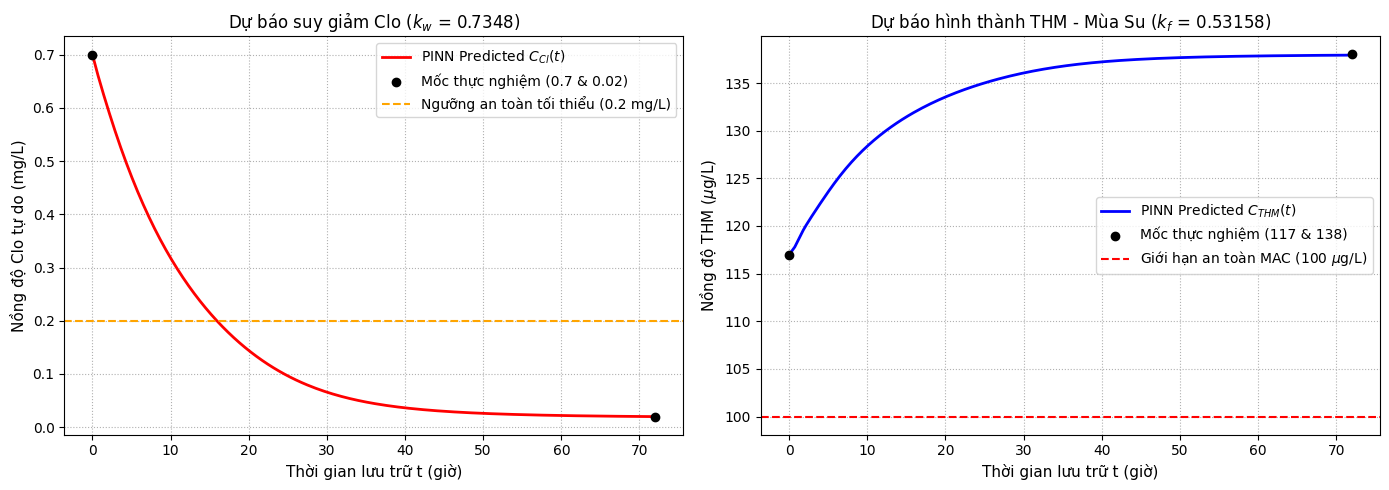

In [ ]:
# Tạo dải thời gian mịn từ 0 đến 72 giờ
t_dense = torch.linspace(t_min, t_max, 200).reshape(-1, 1).to(device)

# Khi lấy dự đoán ra để vẽ đồ thị:
with torch.no_grad():
    pred_dense = model(t_dense).cpu().numpy()

C_pred_np = pred_dense[:, 0]
THM_pred_np = pred_dense[:, 1] * 100.0  # Đổi ngược lại đơn vị ug/L
t_np = t_dense.cpu().numpy()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị 1: Suy giảm Clo
ax1.plot(
    t_np, C_pred_np, "r-", linewidth=2, label="PINN Predicted $C_{Cl}(t)$"
)
ax1.scatter(
    [0, 72],
    [0.7, 0.02],
    color="black",
    zorder=5,
    label="Mốc thực nghiệm (0.7 & 0.02)",
)
ax1.axhline(
    y=0.2,
    color="orange",
    linestyle="--",
    label="Ngưỡng an toàn tối thiểu (0.2 mg/L)",
)
ax1.set_xlabel("Thời gian lưu trữ t (giờ)", fontsize=11)
ax1.set_ylabel("Nồng độ Clo tự do (mg/L)", fontsize=11)
ax1.set_title(f"Dự báo suy giảm Clo ($k_w$ = {model.k_w.item():.4f})")
ax1.grid(True, linestyle=":")
ax1.legend()

# Đồ thị 2: Hình thành THM
ax2.plot(
    t_np, THM_pred_np, "b-", linewidth=2, label="PINN Predicted $C_{THM}(t)$"
)
ax2.scatter(
    [0, 72],
    [THM_initial, THM_end],
    color="black",
    zorder=5,
    label=f"Mốc thực nghiệm ({THM_initial} & {THM_end})",
)
ax2.axhline(
    y=100.0,
    color="red",
    linestyle="--",
    label="Giới hạn an toàn MAC (100 $\mu$g/L)",
)
ax2.set_xlabel("Thời gian lưu trữ t (giờ)", fontsize=11)
ax2.set_ylabel("Nồng độ THM ($\mu$g/L)", fontsize=11)
ax2.set_title(
    f"Dự báo hình thành THM - Mùa {Season} ($k_f$ = {model.k_f.item():.5f})"
)
ax2.grid(True, linestyle=":")
ax2.legend()

plt.tight_layout()
plt.show()